<a href="https://colab.research.google.com/github/laercioives/New-Construtive-Particle-Swarm-Clustering/blob/main/NcPSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando busca otimizada (Randomized Search) com 5-Fold Cross-Validation...

       RESULTADOS DA OTIMIZAÇÃO (5-FOLD)       
Melhores parâmetros:
 {'taxaDeQueda': 0.95, 'ra': 20, 'gama2': 0.9, 'gama1': 40, 'eps2': 0.95, 'eps1': 15, 'MaxIt': 30, 'Inercia': 0.1, 'CentrosPorClasse': 5}
Melhor acurácia média no CV: 0.9733
Taxa de Acerto Geral (Dataset Completo): 0.9733
Quantidade final de partículas: 14



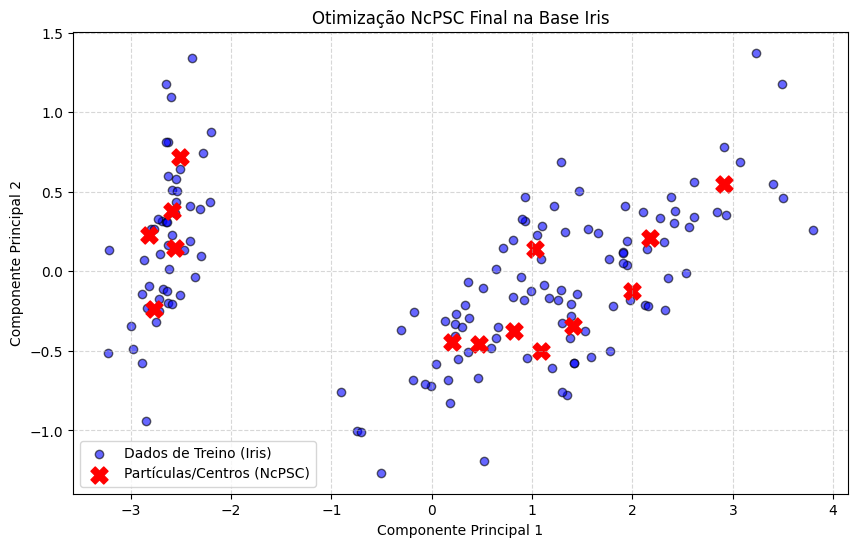

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

class NcPSCClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, NumClasses=3, Inercia=0.5, CentrosPorClasse=5,
                 taxaDeQueda=0.95, eps1=40, eps2=0.95, gama2=0.95,
                 gama1=40, ra=40, MaxIt=30):
        self.NumClasses = NumClasses
        self.Inercia = Inercia
        self.CentrosPorClasse = CentrosPorClasse
        self.taxaDeQueda = taxaDeQueda
        self.eps1 = eps1
        self.eps2 = eps2
        self.gama2 = gama2
        self.gama1 = gama1
        self.ra = ra
        self.MaxIt = MaxIt

        self.PRT_ = None
        self.X_treino_ = None

    def _elimina_pbest(self, Pbest, ind_0):
        return [row[:ind_0] + row[ind_0+1:] for row in Pbest]

    def _add_pbest(self, Pbest, inserir):
        return [row + [np.array(inserir).copy()] for row in Pbest]

    def _subtractive_cluster(self, X):
        rb = 1.25 * self.ra
        C = []
        Nvar = X.shape[1] - 1

        for i in range(1, self.NumClasses + 1):
            qtC = 0
            dados = X[X[:, Nvar] == i]
            tam = dados.shape[0]
            if tam == 0:
                continue

            P = np.zeros(tam)
            for d in range(tam):
                S = 0
                for k in range(tam):
                    # Proteção simples contra divisão por zero se ra for muito pequeno
                    denominador = (self.ra**2) if self.ra != 0 else 1e-6
                    S += np.exp(-4 / denominador * np.linalg.norm(dados[d, :Nvar] - dados[k, :Nvar])**2)
                P[d] = S

            if len(P) == 0: continue
            ind = np.argmax(P)
            P1 = P[ind]

            C.append(np.append(dados[ind, :Nvar], i))
            qtC += 1

            for k in range(tam):
                denominador_b = (rb**2) if rb != 0 else 1e-6
                P[k] -= P1 * np.exp(-4 / denominador_b * np.linalg.norm(dados[ind, :Nvar] - dados[k, :Nvar])**2)

            while qtC < self.CentrosPorClasse:
                ind = np.argmax(P)
                Pk = P[ind]

                C.append(np.append(dados[ind, :Nvar], i))
                qtC += 1

                for k in range(tam):
                    denominador_b = (rb**2) if rb != 0 else 1e-6
                    P[k] -= Pk * np.exp(-4 / denominador_b * np.linalg.norm(dados[ind, :Nvar] - dados[k, :Nvar])**2)

        return np.array(C)

    def _calcula_concentracao(self, PRT, dados):
        Nvar = dados.shape[1] - 1
        conc = Nvar * 2
        classe = Nvar * 2 + 1
        qtVitorias = Nvar * 2 + 2
        AcertoParticula = Nvar * 2 + 3
        raio = Nvar * 2 + 5

        PRT[:, conc] = 0
        PRT[:, qtVitorias] = 0
        PRT[:, raio] = 0

        qtPart = PRT.shape[0]
        qtDados = dados.shape[0]

        ContClasses = np.zeros((qtPart, self.NumClasses + 1))

        for d in range(qtDados):
            dist = np.zeros(qtPart)
            for p in range(qtPart):
                dist[p] = np.linalg.norm(dados[d, :Nvar] - PRT[p, :Nvar])

            vencedora = np.argmin(dist)
            menor = dist[vencedora]

            if PRT[vencedora, raio] < menor:
                PRT[vencedora, raio] = menor

            PRT[vencedora, qtVitorias] += 1
            PRT[vencedora, conc] += 1

            lbl = int(dados[d, Nvar])
            ContClasses[vencedora, lbl] += 1

        for x in range(qtPart):
            maior = ContClasses[x, 1]
            ind = 1
            for d in range(2, self.NumClasses + 1):
                if maior < ContClasses[x, d]:
                    maior = ContClasses[x, d]
                    ind = d

            PRT[x, classe] = ind
            s = np.sum(ContClasses[x, 1:])
            if s > 0:
                PRT[x, AcertoParticula] = maior / s
            else:
                PRT[x, AcertoParticula] = 0

        return PRT

    def fit(self, X, y):
        y_mod = y + 1
        dados_completos = np.hstack([X, y_mod.reshape(-1, 1)])
        self.X_treino_ = dados_completos

        inercia_dinamica = self.Inercia
        Nvar = X.shape[1]
        qtDados = X.shape[0]

        Posicoes = self._subtractive_cluster(dados_completos)
        if Posicoes.size == 0 or len(Posicoes.shape) < 2:
            Posicoes = dados_completos[:self.CentrosPorClasse]

        n_part = Posicoes.shape[0]
        PRT = np.zeros((n_part, Nvar * 2 + 6))

        conc = Nvar * 2
        classe = Nvar * 2 + 1
        qtVitorias = Nvar * 2 + 2
        AcertoParticula = Nvar * 2 + 3
        Estagnada = Nvar * 2 + 4
        raio = Nvar * 2 + 5

        for i in range(n_part):
            PRT[i, :Nvar] = Posicoes[i, :Nvar]
            PRT[i, Nvar:Nvar*2] = 0

        P = [[PRT[j, :Nvar].copy() for j in range(n_part)] for i in range(qtDados)]
        PD = np.zeros((qtDados, n_part))

        for i in range(qtDados):
            for j in range(n_part):
                PD[i, j] = np.linalg.norm(PRT[j, :Nvar] - dados_completos[i, :Nvar])

        G = np.zeros((qtDados, Nvar + 1))
        for i in range(qtDados):
            ind = np.argmin(PD[i, :])
            v = PD[i, ind]
            G[i, :Nvar] = P[i][ind]
            G[i, Nvar] = v

        PRT = self._calcula_concentracao(PRT, dados_completos)

        for it in range(1, int(self.MaxIt) + 1):
            n_part = PRT.shape[0]
            for j in range(n_part):
                if PRT[j, AcertoParticula] > self.gama2 and PRT[j, conc] > self.gama1:
                    PRT[j, Estagnada] = 1
                else:
                    PRT[j, Estagnada] = 0

            PRT[:, qtVitorias] = 0

            for i in range(qtDados):
                S = np.zeros((n_part, 2))
                for j in range(n_part):
                    S[j, 0] = np.linalg.norm(PRT[j, :Nvar] - dados_completos[i, :Nvar])
                    S[j, 1] = j

                ind = np.argmin(S[:, 0])
                v = S[ind, 0]
                vnc = int(S[ind, 1])

                if v < PD[i, vnc]:
                    PD[i, vnc] = v
                    P[i][vnc] = PRT[vnc, :Nvar].copy()
                    if v < G[i, Nvar]:
                        G[i, Nvar] = v
                        G[i, :Nvar] = PRT[vnc, :Nvar].copy()

                PRT[vnc, qtVitorias] += 1

                if PRT[vnc, Estagnada] == 0:
                    r1, r2, r3 = np.random.rand(Nvar), np.random.rand(Nvar), np.random.rand(Nvar)
                    PRT[vnc, Nvar:Nvar*2] = inercia_dinamica * (PRT[vnc, Nvar:Nvar*2] +
                                                       r1 * (P[i][vnc] - PRT[vnc, :Nvar]) +
                                                       r2 * (G[i, :Nvar] - PRT[vnc, :Nvar]) +
                                                       r3 * (dados_completos[i, :Nvar] - PRT[vnc, :Nvar]))
                    PRT[vnc, :Nvar] += PRT[vnc, Nvar:Nvar*2]

            if it % 2 == 1:
                j = 0
                while j < PRT.shape[0]:
                    if PRT[j, qtVitorias] == 0:
                        PRT = np.delete(PRT, j, axis=0)
                        PD = np.delete(PD, j, axis=1)
                        P = self._elimina_pbest(P, j)
                    else:
                        j += 1

            PRT = self._calcula_concentracao(PRT, dados_completos)
            n_part = PRT.shape[0]

            if it % 2 == 0:
                i_cl = 0
                while i_cl < n_part:
                    if PRT[i_cl, conc] > self.eps1 and PRT[i_cl, AcertoParticula] < self.eps2:
                        clonada = i_cl
                        NovaParticula = PRT[clonada, :].copy()

                        var = np.random.randint(0, Nvar)
                        s = 1 if np.random.rand() < 0.5 else -1

                        NovaParticula[var] = s * np.random.rand() * 0.01 * NovaParticula[var] + NovaParticula[var]
                        NovaParticula[classe] = 0
                        NovaParticula[conc] = 0
                        NovaParticula[qtVitorias] = 0
                        NovaParticula[AcertoParticula] = 0
                        NovaParticula[Nvar:Nvar*2] = 0

                        PRT = np.vstack([PRT, NovaParticula])

                        Distancias = []
                        for k in range(qtDados):
                            Distancias.append(np.linalg.norm(NovaParticula[:Nvar] - dados_completos[k, :Nvar]))

                        P = self._add_pbest(P, NovaParticula[:Nvar])
                        PD = np.hstack([PD, np.array(Distancias).reshape(-1, 1)])
                        PRT = self._calcula_concentracao(PRT, dados_completos)
                        n_part = PRT.shape[0]
                    i_cl += 1

            inercia_dinamica *= self.taxaDeQueda

        self.PRT_ = self._calcula_concentracao(PRT, dados_completos)
        return self

    def predict(self, X):
        Nvar = X.shape[1]
        preds = []
        classe_idx = Nvar * 2 + 1

        for i in range(X.shape[0]):
            dists = [np.linalg.norm(X[i, :Nvar] - p[:Nvar]) for p in self.PRT_]
            vencedora = np.argmin(dists)
            preds.append(int(self.PRT_[vencedora, classe_idx]) - 1)
        return np.array(preds)


# --- BUSCA DE PARÂMETROS E PLOT ---
if __name__ == "__main__":
    iris = load_iris()
    X = iris.data
    y = iris.target

    # Espaço de busca completo solicitado
    param_distributions = {
        'Inercia': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
        'CentrosPorClasse': [2, 3, 5, 8],
        'taxaDeQueda': [0.8, 0.9, 0.95, 0.98],
        'eps1': [10, 15, 20, 25, 30, 40],
        'eps2': [0.8, 0.85, 0.9, 0.95],
        'gama2': [0.8, 0.85, 0.9, 0.95],
        'gama1': [10, 15, 20, 25, 30, 40],
        'ra': [20, 25, 30, 40, 50, 60],
        'MaxIt': [10, 20, 30, 40, 50]
    }

    print("Iniciando busca otimizada (Randomized Search) com 5-Fold Cross-Validation...")
    base_estimator = NcPSCClassifier(NumClasses=3)

    # n_iter=50 seleciona 50 combinações aleatórias viáveis do bilhão de possibilidades
    search = RandomizedSearchCV(base_estimator, param_distributions, n_iter=50,
                                cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    search.fit(X, y)

    # 1. Melhores Parâmetros encontrados
    print("\n===============================================")
    print("       RESULTADOS DA OTIMIZAÇÃO (5-FOLD)       ")
    print("===============================================")
    print(f"Melhores parâmetros:\n {search.best_params_}")
    print(f"Melhor acurácia média no CV: {search.best_score_:.4f}")

    # 2. Avaliação da Taxa de Acerto Geral no dataset completo
    melhor_modelo = search.best_estimator_
    y_pred = melhor_modelo.predict(X)
    acuracia_geral = accuracy_score(y, y_pred)
    print(f"Taxa de Acerto Geral (Dataset Completo): {acuracia_geral:.4f}")
    print(f"Quantidade final de partículas: {melhor_modelo.PRT_.shape[0]}")
    print("===============================================\n")

    # 3. Geração do gráfico de dispersão (PCA 2D)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    Nvar_dim = X.shape[1]
    particulas_posicoes = melhor_modelo.PRT_[:, :Nvar_dim]
    particulas_pca = pca.transform(particulas_posicoes)

    plt.figure(figsize=(10, 6))

    # Dados de treino na cor azul
    plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', alpha=0.6, label='Dados de Treino (Iris)', edgecolors='k')

    # Partículas/Centros encontrados na cor vermelha
    plt.scatter(particulas_pca[:, 0], particulas_pca[:, 1], color='red', s=150, marker='X', label='Partículas/Centros (NcPSC)')

    plt.title('Otimização NcPSC Final na Base Iris')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()